#Synthetic Digital Breast Tomosynthesis Dataset with Breast Tumor Segmentation Masks    
Cristina Alfaro Vergara, Nicolás Araya, Claudia Prieto and Domingo
Mery

## download dataset

In [ ]:
!wget https://www.dropbox.com/scl/fi/3xc8od72i9952rndkpgmb/dataset_174_nuevo.zip?rlkey=nbf50v4j9snyj4eiyi2o9xv94&st=opo7rjlb&dl=0
!mv /content/dataset_174_nuevo.zip?rlkey=nbf50v4j9snyj4eiyi2o9xv94 dataset_174_nuevo.zip
!unzip -qq dataset_174_nuevo.zip
!rm /content/dataset_174_nuevo.zip

--2024-12-06 18:53:44--  https://www.dropbox.com/scl/fi/3xc8od72i9952rndkpgmb/dataset_174_nuevo.zip?rlkey=nbf50v4j9snyj4eiyi2o9xv94
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc547924a79335f5a27806e90316.dl.dropboxusercontent.com/cd/0/inline/CfwwtI98l1McLw5oI2JdhNpdiVa_6LrLia4SHv3yy3Gfi7XTC3Kt__4NQ_i2bhcgpBuw0JTNXUje3dQ1f7NV9L2Cx49MFicpF2CQ9ETTnCYqhnuxSU13CgpFvb0CK8RAZQWq41cBNtkzXmf1MPHPEOOY/file# [following]
--2024-12-06 18:53:45--  https://uc547924a79335f5a27806e90316.dl.dropboxusercontent.com/cd/0/inline/CfwwtI98l1McLw5oI2JdhNpdiVa_6LrLia4SHv3yy3Gfi7XTC3Kt__4NQ_i2bhcgpBuw0JTNXUje3dQ1f7NV9L2Cx49MFicpF2CQ9ETTnCYqhnuxSU13CgpFvb0CK8RAZQWq41cBNtkzXmf1MPHPEOOY/file
Resolving uc547924a79335f5a27806e90316.dl.dropboxusercontent.com (uc547924a79335f5a27806e90316.dl.dropboxusercontent.com)... 162.125.4.1

## install libraries

In [ ]:
%%capture
!pip install lightning segmentation-models-pytorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, Subset

from torchvision import models
import numpy as np
from PIL import Image

from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import ModelCheckpoint

from torch.optim import lr_scheduler

import os
import segmentation_models_pytorch as smp
import lightning as L

import torch.nn.functional as F
import matplotlib.pyplot as plt
import fnmatch

from   skimage.color import label2rgb
from sklearn.model_selection import StratifiedShuffleSplit



from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights



device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('Device:', device)

Device: cuda


##Dataset customize

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        """
        Initializes the CustomDataset class.

        Args:
            image_dir (str): Path to the directory containing image files.
            mask_dir (str): Path to the directory containing mask files.
            transform (callable, optional): Transformations to apply to images and masks.

        Attributes:
            image_files (list): Sorted list of image file names in `image_dir`.
            mask_files (list): Sorted list of mask file names in `mask_dir`.
            labels (np.ndarray): Array of labels extracted from the mask files.
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # Collect all image and mask file names and sort them
        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.tif')])
        self.mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith('.tif')])

        # Ensure the number of images matches the number of masks
        assert len(self.image_files) == len(self.mask_files), "The number of images and masks must match."

        # Extract labels from the masks
        self.labels = self._extract_labels_from_masks()

    def _extract_labels_from_masks(self):
        """
        Extracts unique labels from the mask files.

        Returns:
            np.ndarray: Array of labels derived from the masks.
        """
        labels = []
        for mask_file in self.mask_files:
            mask_path = os.path.join(self.mask_dir, mask_file)
            mask = Image.open(mask_path).convert('L')  # Open mask and convert it to grayscale
            mask_array = np.array(mask)  # Convert the mask to a NumPy array
            unique_values = np.unique(mask_array)  # Get unique pixel values

            # If masks are binary, use the predominant value for labeling
            if len(unique_values) > 1:
                label = unique_values[1]  # Assume the second value is relevant
            else:
                label = unique_values[0]  # Use the single unique value

            labels.append(label)

        return np.array(labels)

    def __len__(self):
        """
        Returns the total number of samples in the dataset.

        Returns:
            int: Number of image-mask pairs.
        """
        return len(self.image_files)

    def __getitem__(self, idx):
        """
        Retrieves the image and mask at the specified index.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            tuple: A tuple containing the image and its corresponding mask.
        """
        # Get the file paths for the image and mask
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        # Open the image and mask as grayscale
        image = Image.open(image_path).convert('L')
        mask = Image.open(mask_path).convert('L')

        # Apply transformations if specified
        if self.transform:
            if image:
                image = self.transform(image)
            if mask:
                mask = self.transform(mask)

        return image, mask


In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images and masks to 128x128 resolution
    transforms.ToTensor(),         # Convert PIL images to PyTorch tensors
    # transforms.RandomHorizontalFlip(p=0.5),  # Optionally apply random horizontal flipping
])

image_dir = "dataset_174_nuevo/images"  # Directory containing the image files
mask_dir = "dataset_174_nuevo/masks"    # Directory containing the mask files
dataset = CustomDataset(image_dir, mask_dir, transform=transform)

labels = dataset.labels  # Extract the precomputed labels from the dataset

In [ ]:
# Configure StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
# Creates a stratified splitter that maintains the distribution of labels across splits.
# - n_splits=5: Number of re-shuffling splits.
# - test_size=0.2: 20% of the dataset will be used as the test set.
# - random_state=42: Ensures reproducibility of the split.

# Perform the first split: Train/Validation + Test
train_val_indices, test_indices = next(split.split(np.zeros(len(labels)), labels))
# Splits the dataset into training/validation (80%) and testing (20%).
# `np.zeros(len(labels))`: Placeholder input for features since only labels are used for stratification.

# Perform the second split: Train and Validation
train_indices, val_indices = next(split.split(np.zeros(len(train_val_indices)), labels[train_val_indices]))
# Splits the training/validation set into separate training (80%) and validation (20%) subsets,
# maintaining the label distribution within the train/validation indices.

# Create subsets for train, validation, and test
train_dataset = Subset(dataset, train_indices)
# `train_dataset` contains only the data corresponding to the indices in `train_indices`.

val_dataset = Subset(dataset, val_indices)
# `val_dataset` contains only the data corresponding to the indices in `val_indices`.

test_dataset = Subset(dataset, test_indices)
# `test_dataset` contains only the data corresponding to the indices in `test_indices`.

# Create data loaders for the subsets
train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True, num_workers=os.cpu_count())
# DataLoader for training:
# - `batch_size=20`: Each batch will contain 20 samples.
# - `shuffle=True`: Shuffles the data for each epoch to enhance training generalization.
# - `num_workers=os.cpu_count()`: Utilizes the maximum number of available CPU cores for data loading.

val_loader = DataLoader(val_dataset, batch_size=20, shuffle=False, num_workers=os.cpu_count())
# DataLoader for validation:
# - No shuffling as the data order is not critical for validation.

test_loader = DataLoader(test_dataset, batch_size=20, shuffle=False, num_workers=os.cpu_count())
# DataLoader for testing:
# - Similarly, no shuffling to ensure consistency in results.


In [ ]:
EPOCHS = 100
T_MAX = EPOCHS * len(train_loader)

##Unet model

In [ ]:
class Block(nn.Module):
    def __init__(self, inputs = 1, middles = 64, outs = 64):
        super().__init__()

        self.conv1 = nn.Conv2d(inputs, middles, 3, 1, 1)
        self.conv2 = nn.Conv2d(middles, outs, 3, 1, 1)
        self.relu = nn.ReLU()
        self.bn = nn.BatchNorm2d(outs)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):

        x = self.relu(self.conv1(x))
        x = self.relu(self.bn(self.conv2(x)))
        # e1 = x
        # x = self.pool(x)

        return self.pool(x), x
        # self.pool(x): [bs, out, h*.5, w*.5]
        # x: [bs, out, h, w]

        # return x, e1
        # x: [bs, out, h*.5, w*.5]
        # e1: [bs, out, h, w]

In [ ]:
class UNet(nn.Module):
    def __init__(self,):
        super().__init__()
        #self.device = device
        #self.dropout = nn.Dropout(dropout)

        self.en1 = Block(1, 64, 64)
        self.en2 = Block(64, 128, 128)
        self.en3 = Block(128, 256, 256)
        self.en4 = Block(256, 512, 512)
        self.en5 = Block(512, 1024, 512)

        self.upsample4 = nn.ConvTranspose2d(512, 512, 2, stride = 2)
        self.de4 = Block(1024, 512, 256)

        self.upsample3 = nn.ConvTranspose2d(256, 256, 2, stride = 2)
        self.de3 = Block(512, 256, 128)

        self.upsample2 = nn.ConvTranspose2d(128, 128, 2, stride = 2)
        self.de2 = Block(256, 128, 64)

        self.upsample1 = nn.ConvTranspose2d(64, 64, 2, stride = 2)
        self.de1 = Block(128, 64, 64)

        self.conv_last = nn.Conv2d(64, 1, kernel_size=1, stride = 1, padding = 0)

    def forward(self, x):
        # x: [bs, 3, 256, 256]

        x, e1 = self.en1(x)
        # x: [bs, 64, 128, 128]
        # e1: [bs, 64, 256, 256]
        #print(f"enc 1: x:{x.shape} - e1:{e1.shape}" )

        x, e2 = self.en2(x)
        # x: [bs, 128, 64, 64]
        # e2: [bs, 128, 128, 128]
        #print(f"enc 2: x:{x.shape} - e2:{e2.shape}" )

        x, e3 = self.en3(x)
        # x: [bs, 256, 32, 32]
        # e3: [bs, 256, 64, 64]
        #print(f"encv3: x:{x.shape} - e3:{e3.shape}" )

        x, e4 = self.en4(x)
        # x: [bs, 512, 16, 16]
        # e4: [bs, 512, 32, 32]
        #print(f"encv4: x:{x.shape} - e4:{e4.shape}" )

        _, x = self.en5(x)
        # x: [bs, 512, 16, 16]
        #print(f"encv5: x:{x.shape}" )

        x = self.upsample4(x)
        # x: [bs, 512, 32, 32]
        #print(f"upsample 4: x:{x.shape}" )
        x = torch.cat([x, e4], dim=1)
        # x: [bs, 1024, 32, 32]
        _,  x = self.de4(x)
        #print(f"dec 4: x:{x.shape}" )
        # x: [bs, 256, 32, 32]

        x = self.upsample3(x)
        #print(f"dec 3: x:{x.shape}" )
        # x: [bs, 256, 64, 64]
        x = torch.cat([x, e3], dim=1)
        # x: [bs, 512, 64, 64]
        _, x = self.de3(x)
        # x: [bs, 128, 64, 64]

        x = self.upsample2(x)
        # x: [bs, 128, 128, 128]
        x = torch.cat([x, e2], dim=1)
        # x: [bs, 256, 128, 128]
        _, x = self.de2(x)
        # x: [bs, 64, 128, 128]

        x = self.upsample1(x)
        # x: [bs, 64, 256, 256]
        x = torch.cat([x, e1], dim=1)
        # x: [bs, 128, 256,256, 256
        _, x = self.de1(x)
        # x: [bs, 64, 256, 256]

        x = self.conv_last(x)
        # x: [bs, 1, 256, 256]

        # x = x.squeeze(1)
        return x

In [ ]:
class UNETModel(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = UNet()
        self.loss_fn = torch.nn.BCEWithLogitsLoss()


        # Initialize lists to store results for each epoch
        self.training_step_outputs = []
        self.validation_step_outputs = []
        self.test_step_outputs = []

        # Initialize lists to store accumulated metrics
        self.train_metrics = []
        self.valid_metrics = []
        self.test_metrics = []

    def forward(self, image):
        mask = self.model(image)
        return mask

    def shared_step(self, batch, stage):
        image = batch[0]
        mask = batch[1]

        logits_mask = self.forward(image)
        loss = self.loss_fn(logits_mask, mask)

        prob_mask = logits_mask.sigmoid()
        pred_mask = (prob_mask > 0.5).float()

        tp, fp, fn, tn = smp.metrics.get_stats(pred_mask.long(), mask.long(), mode="binary")

        return {
            "loss": loss,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        }

    def shared_epoch_end(self, outputs, stage):
        tp = torch.cat([x["tp"] for x in outputs])
        fp = torch.cat([x["fp"] for x in outputs])
        fn = torch.cat([x["fn"] for x in outputs])
        tn = torch.cat([x["tn"] for x in outputs])

        total_loss = sum(x['loss'].item() for x in outputs)
        iter_count = len(outputs)

        per_image_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro-imagewise")
        dataset_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")

        recall = smp.metrics.recall(tp, fp, fn, tn, reduction="micro")
        precision = smp.metrics.precision(tp, fp, fn, tn, reduction="micro")

        f1_score = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro")
        accuracy = smp.metrics.accuracy(tp, fp, fn, tn, reduction="macro")

        metrics = {
            f"{stage}_loss": total_loss / iter_count,
            f"{stage}_precision": precision,
            f"{stage}_recall": recall,
            f"{stage}_accuracy": accuracy,
            f"{stage}_f1_score": f1_score,
            f"{stage}_per_image_iou": per_image_iou,
            f"{stage}_dataset_iou": dataset_iou,
        }

        # Log metrics
        self.log_dict(metrics, prog_bar=True)

        # Append metrics to the corresponding list
        if stage == "train":
            self.train_metrics.append(metrics)
        elif stage == "valid":
            self.valid_metrics.append(metrics)
        elif stage == "test":
            self.test_metrics.append(metrics)

    def training_step(self, batch, batch_idx):
        output = self.shared_step(batch, "train")
        self.training_step_outputs.append(output)
        return output["loss"]

    def on_train_epoch_end(self):
        self.shared_epoch_end(self.training_step_outputs, "train")
        self.training_step_outputs.clear()  # free memory

    def validation_step(self, batch, batch_idx):
        output = self.shared_step(batch, "valid")
        self.validation_step_outputs.append(output)
        return output["loss"]

    def on_validation_epoch_end(self):
        self.shared_epoch_end(self.validation_step_outputs, "valid")
        self.validation_step_outputs.clear()  # free memory

    def test_step(self, batch, batch_idx):
        output = self.shared_step(batch, "test")
        self.test_step_outputs.append(output)
        return output["loss"]

    def on_test_epoch_end(self):
        self.shared_epoch_end(self.test_step_outputs, "test")
        self.test_step_outputs.clear()  # free memory

    def configure_optimizers(self):
      return torch.optim.Adam(self.parameters(), lr=1e-4)


    def save_test_metrics(self):
        test_df = pd.DataFrame({
            "model": ["unet"],
            "test_precision": [self.test_metrics[0]['test_precision'].item()],
            "test_recall": [self.test_metrics[0]['test_recall'].item()],
            "test_f1_score": [self.test_metrics[0]['test_f1_score'].item()],
            "test_per_image_iou": [self.test_metrics[0]['test_per_image_iou'].item()],
            "test_dataset_iou": [self.test_metrics[0]['test_dataset_iou'].item()],
            "test_loss": [self.test_metrics[0]['test_loss']],
            "test_accuracy": [self.test_metrics[0]['test_accuracy'].item()],
            })
        # Save to CSV files
        test_df.to_csv("unet_test_metrics.csv", index=False)

In [ ]:
from lightning.pytorch.callbacks import ModelCheckpoint
# model
unet_model = UNETModel().to(device)

early_stop = EarlyStopping(monitor= "valid_f1_score",
                           min_delta=0.00,
                           patience = 20,
                           verbose=True,
                           mode="max")
checkpoint_callback = ModelCheckpoint( monitor='valid_f1_score',
                                      dirpath='/content/models',
                                       filename='unet-{epoch:02d}-{valid_f1_score:.2f}',
                                       mode='max',  # save model with best valid_f1_score value
                                       save_top_k=1,  # save best model
                                       )
## Scheduler
SWA = L.pytorch.callbacks.StochasticWeightAveraging(swa_lrs=1e-2)

# train model
trainer = L.Trainer(
    #logger = wandb_logger,

    max_epochs= EPOCHS,
    callbacks=[early_stop, SWA,checkpoint_callback]
    )


trainer.fit(model=unet_model, train_dataloaders=train_loader,val_dataloaders=val_loader)
trainer.test(unet_model, dataloaders=test_loader)
# Guardar métricas
unet_model.save_test_metrics()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /content/models exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | model   | UNet              | 23.4 M | train
1 | loss_fn | BCEWithLogitsLoss | 0      | train
------------------------------------------------------
23.4 M    Trainable params
0         Non-trainable params
23.4 M    Tot

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric valid_f1_score did not improve in the last 20 records. Best score: 0.855. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric valid_f1_score did not improve in the last 20 records. Best score: 0.855. Signaling Trainer to stop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.9861014485359192     │
│     test_dataset_iou      │    0.8565049767494202     │
│       test_f1_score       │    0.9227069020271301     │
│         test_loss         │     0.131630539894104     │
│    test_per_image_iou     │    0.8531697988510132     │
│      test_precision       │    0.9576648473739624     │
│        test_recall        │     0.890211284160614     │
└───────────────────────────┴───────────────────────────┘

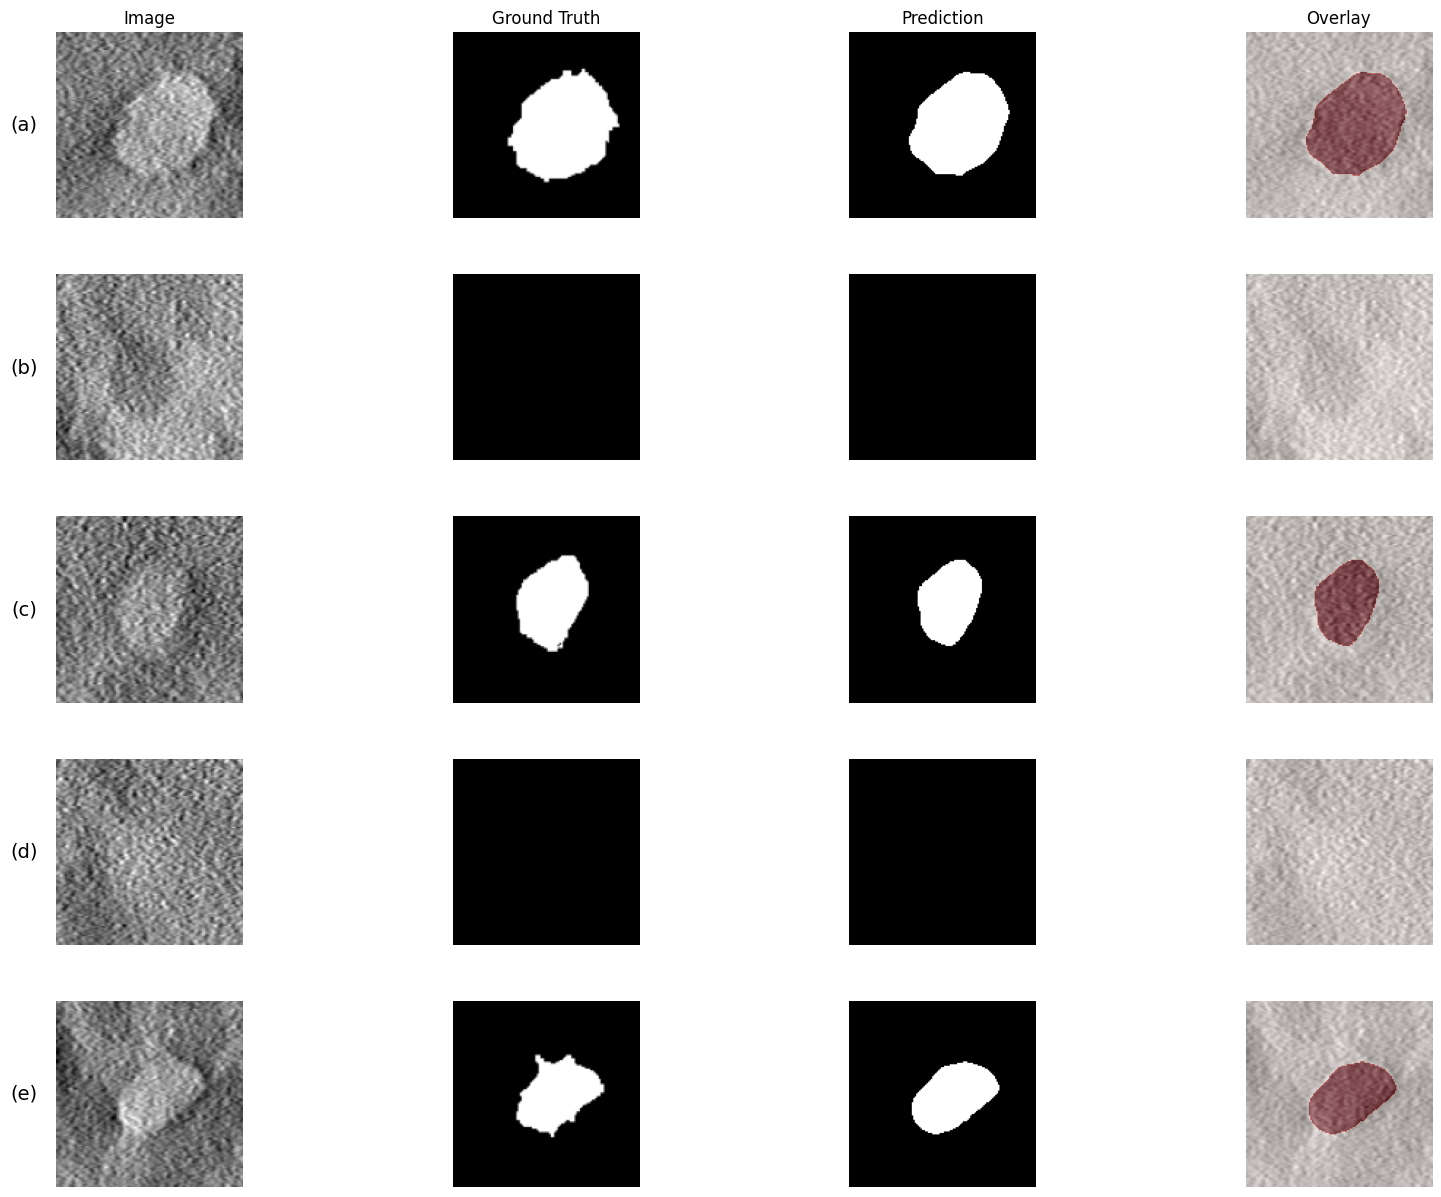

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Obtén un lote de datos
batch = next(iter(test_loader))
with torch.no_grad():
    unet_model.eval()
    logits = unet_model(batch[0])
pr_masks = (logits.sigmoid() > .5).float()

# Número de filas a mostrar
num_rows = 5

# Crear una figura con subplots
fig, axs = plt.subplots(num_rows, 4, figsize=(20, 15))
plt.subplots_adjust(wspace=0.1, hspace=0.3)

# Títulos de las columnas
titles = ["Image", "Ground Truth", "Prediction", "Overlay"]

for i in range(num_rows):
    image, gt_mask, pr_mask = batch[0][i], batch[1][i], pr_masks[i]

    # Imagen original
    axs[i, 0].imshow(image.detach().cpu().numpy().transpose(1, 2, 0), cmap="gray")
    axs[i, 0].axis("off")

    # Máscara de verdad del terreno
    axs[i, 1].imshow(gt_mask.squeeze().detach().cpu().numpy(), cmap="gray")
    axs[i, 1].axis("off")

    # Máscara de predicción
    axs[i, 2].imshow(pr_mask.squeeze().numpy(), cmap="gray")
    axs[i, 2].axis("off")

    # Imagen con la predicción superpuesta
    image_np = image.detach().cpu().numpy().transpose(1, 2, 0)
    pr_mask_np = pr_mask.squeeze().numpy()
    axs[i, 3].imshow(image_np, cmap="gray")
    axs[i, 3].imshow(pr_mask_np, alpha=0.5, cmap="Reds")
    axs[i, 3].axis("off")

# Añadir títulos de columnas solo en la primera fila
for ax, title in zip(axs[0], titles):
    ax.set_title(title)

# Añadir etiquetas a la izquierda de las imágenes
labels = ["(a)", "(b)", "(c)", "(d)", "(e)"]
for i, label in enumerate(labels):
    axs[i, 0].text(-0.1, 0.5, label, transform=axs[i, 0].transAxes, fontsize=14, va='center', ha='right')

# Guardar la figura en formatos PNG y PDF
plt.savefig('images_and_masks.png', bbox_inches='tight')
plt.savefig('images_and_masks.pdf', bbox_inches='tight')
plt.show()



In [ ]:
 import matplotlib.pyplot as plt
import pandas as pd

def plot_and_save_training_validation_loss(train_metrics, valid_metrics, output_dir="results"):
    # Crear el directorio si no existe
    import os
    os.makedirs(output_dir, exist_ok=True)

    # Extraer pérdidas
    training_losses = [metric["train_loss"] for metric in train_metrics]
    validation_losses = [metric["valid_loss"] for metric in valid_metrics]

    # Crear la gráfica
    plt.figure(figsize=(10, 6))
    plt.plot(training_losses, label="Training Loss", marker="o", color="blue")
    plt.plot(validation_losses, label="Validation Loss", marker="o", color="orange")

    plt.title("Training and Validation Loss per Epoch", fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Loss", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)

    # Guardar gráfico en PDF y PNG
    plt.savefig(f"{output_dir}/training_validation_loss.pdf", format="pdf")
    plt.savefig(f"{output_dir}/training_validation_loss.png", format="png")
    plt.close()  # Cerrar la figura para liberar memoria

    # Guardar métricas en CSV
    train_data = pd.DataFrame(train_metrics)
    valid_data = pd.DataFrame(valid_metrics)

    # Agregar prefijo a las columnas para identificar las métricas
    train_data = train_data.add_prefix("train_")
    valid_data = valid_data.add_prefix("valid_")

    # Combinar en un solo DataFrame para exportar
    combined_data = pd.concat([train_data, valid_data], axis=1)
    combined_data.to_csv(f"{output_dir}/metrics.csv", index=False)

    print(f"Gráfico guardado en {output_dir} y métricas exportadas como CSV.")

# Llamar a la función con el modelo entrenado
plot_and_save_training_validation_loss(unet_model.train_metrics, unet_model.valid_metrics)


Gráfico guardado en results y métricas exportadas como CSV.
